# 07 — MUSIC Robustness to Wrong Source Count

**Goal**: determine how MUSIC degrades when `n_sources` is mis-specified.

MUSIC partitions the N-dimensional signal space into a signal subspace
(spanned by the k largest eigenvectors) and a noise subspace (the remaining
N−k eigenvectors).  The spectrum is the inverse projection of each steering
vector onto the noise subspace.  When k is wrong:

- **Undercount (n_sources < true k)**: the signal subspace is too small;
  some signal energy leaks into the noise subspace.  True source peaks may
  weaken or merge.
- **Overcount (n_sources > true k)**: the signal subspace is too large;
  some noise eigenvectors are absorbed into the signal subspace, reducing
  the noise subspace.  Spurious peaks can appear at directions corresponding
  to excluded noise eigenvectors.

Key questions:
1. Does undercount still resolve two sources at typical SNR?
2. Does overcount create false detections?
3. At what SNR does mismatch become tolerable/intolerable?
4. Does higher N_SNAP compensate for mismatch?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv
from scipy.signal import find_peaks

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MIN  = 0.025
R_MAX  = 0.150
FS     = 48_000
FREQ   = 4000.0
N_SNAP = 256
SNR_DB = 20.0


In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)
N_MICS = len(x_arr)
print(f'N_MICS = {N_MICS}')


N_MICS = 96


In [3]:
def steering_vector(x, y, az_deg, freq):
    u = np.sin(np.radians(az_deg))
    return np.exp(1j * 2 * np.pi * freq / C * u * x) / np.sqrt(len(x))


def steering_matrix(x, y, az_grid, freq):
    u = np.sin(np.radians(az_grid))
    phase = 2 * np.pi * freq / C * np.outer(x, u)
    return np.exp(1j * phase) / np.sqrt(len(x))


def make_csm(x, y, sources, freq, snr_db, n_snap, seed=None):
    local_rng = np.random.default_rng(seed)
    N = len(x)
    max_power = max(p for _, p in sources)
    noise_var = max_power / (10 ** (snr_db / 10))
    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for az, power in sources:
            h = steering_vector(x, y, az, freq)
            s = local_rng.standard_normal() + 1j * local_rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        noise = local_rng.standard_normal(N) + 1j * local_rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap


def beamform_music(x, y, R, freq, az_grid, n_sources=1):
    _, eigvecs = np.linalg.eigh(R)
    E_n = eigvecs[:, :R.shape[0] - n_sources]
    En_proj = E_n @ E_n.conj().T
    H = steering_matrix(x, y, az_grid, freq)
    denom = np.real(np.sum(H.conj() * (En_proj @ H), axis=0))
    return 1.0 / np.maximum(denom, 1e-300)


def db_norm(x):
    return 10 * np.log10(x / x.max())


def detect_peaks(az_grid, music_map, min_rel=0.05, min_sep_deg=5.0):
    """Return azimuth angles of local maxima above min_rel * global_max."""
    m_norm = music_map / music_map.max()
    min_dist = max(1, int(min_sep_deg / (az_grid[1] - az_grid[0])))
    idx, _ = find_peaks(m_norm, height=min_rel, distance=min_dist)
    return az_grid[idx]


az_grid = np.linspace(-60, 60, 1201)


## 1 — Spectrum Comparison: Under- and Over-count

Fix SNR=20dB, N_SNAP=256, single CSM realisation (seed=42).
Left block: 2 true sources at ±15°, n_sources varied 1–4.
Right block: 1 true source at 20°, n_sources varied 1–4.


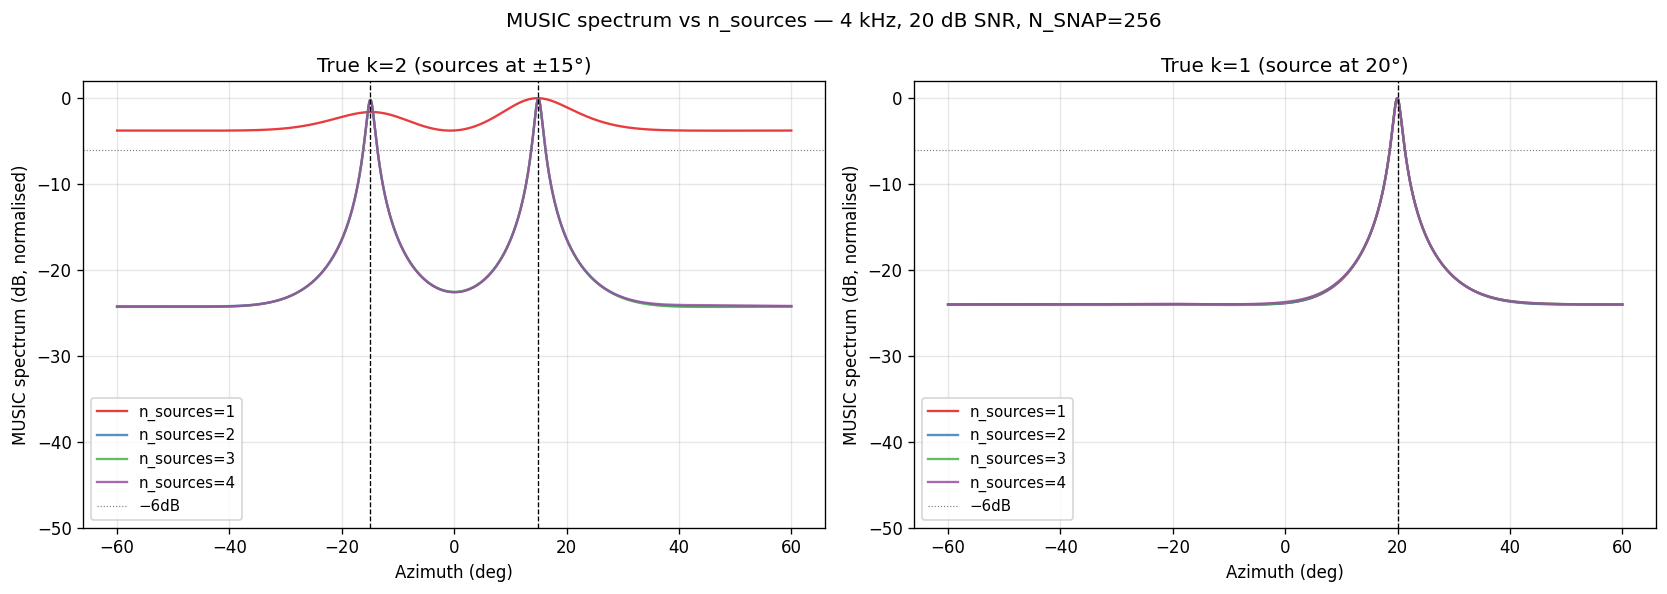

In [4]:
src_two  = [(-15.0, 1.0), (15.0, 1.0)]
src_one  = [(20.0, 1.0)]
n_range  = [1, 2, 3, 4]
colors_n = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

R2 = make_csm(x_arr, y_arr, src_two, FREQ, SNR_DB, N_SNAP, seed=42)
R1 = make_csm(x_arr, y_arr, src_one, FREQ, SNR_DB, N_SNAP, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, R, sources, title in [
    (axes[0], R2, src_two, 'True k=2 (sources at ±15°)'),
    (axes[1], R1, src_one, 'True k=1 (source at 20°)'),
]:
    for n_spec, col in zip(n_range, colors_n):
        m = beamform_music(x_arr, y_arr, R, FREQ, az_grid, n_sources=n_spec)
        ax.plot(az_grid, db_norm(m), color=col, label=f'n_sources={n_spec}',
                linewidth=1.4, alpha=0.85)
    for az, _ in sources:
        ax.axvline(az, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(-6, color='gray', linestyle=':', linewidth=0.7, label='−6dB')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('MUSIC spectrum (dB, normalised)')
    ax.set_title(title)
    ax.set_ylim(-50, 2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'MUSIC spectrum vs n_sources — {FREQ/1000:.0f} kHz, {SNR_DB:.0f} dB SNR, N_SNAP={N_SNAP}')
plt.tight_layout()
plt.savefig('music_spectrum_mismatch.png', dpi=150, bbox_inches='tight')
plt.show()


## 2 — Peak Counts vs n_sources Specification

For each CSM, count detected peaks (local maxima above 5% of global max,
separated by ≥5°).  Ideal: count equals true source count.

Average over N_TRIALS=20 realisations to get stable estimates.


In [5]:
N_TRIALS = 20

rows = []
for true_k, sources, src_label in [
    (1, src_one,  '1 source @ 20°'),
    (2, src_two,  '2 sources @ ±15°'),
]:
    for n_spec in [1, 2, 3, 4]:
        peak_counts = []
        for trial in range(N_TRIALS):
            R = make_csm(x_arr, y_arr, sources, FREQ, SNR_DB, N_SNAP,
                         seed=trial * 1000 + n_spec)
            m = beamform_music(x_arr, y_arr, R, FREQ, az_grid, n_sources=n_spec)
            peaks = detect_peaks(az_grid, m)
            peak_counts.append(len(peaks))
        rows.append({
            'True k': true_k,
            'Sources': src_label,
            'n_sources specified': n_spec,
            'Mismatch': n_spec - true_k,
            'Mean peak count': round(np.mean(peak_counts), 2),
            'Std': round(np.std(peak_counts), 2),
        })

df_peaks = pd.DataFrame(rows)
print(df_peaks.to_string(index=False))


 True k          Sources  n_sources specified  Mismatch  Mean peak count  Std
      1   1 source @ 20°                    1         0              1.0 0.00
      1   1 source @ 20°                    2         1              1.0 0.00
      1   1 source @ 20°                    3         2              1.0 0.00
      1   1 source @ 20°                    4         3              1.0 0.00
      2 2 sources @ ±15°                    1        -1              3.0 0.89
      2 2 sources @ ±15°                    2         0              2.0 0.00
      2 2 sources @ ±15°                    3         1              2.0 0.00
      2 2 sources @ ±15°                    4         2              2.0 0.00


## 3 — Detection Rate vs SNR for Undercounted MUSIC

Scenario: 2 true sources at ±15°, **n_sources=1** (undercount by 1).
For each SNR, run N_TRIALS CSM realisations.  Count the fraction where
**both** true sources are detected (peak within ±5° of each true direction).
Compare with correctly-specified n_sources=2 as reference.


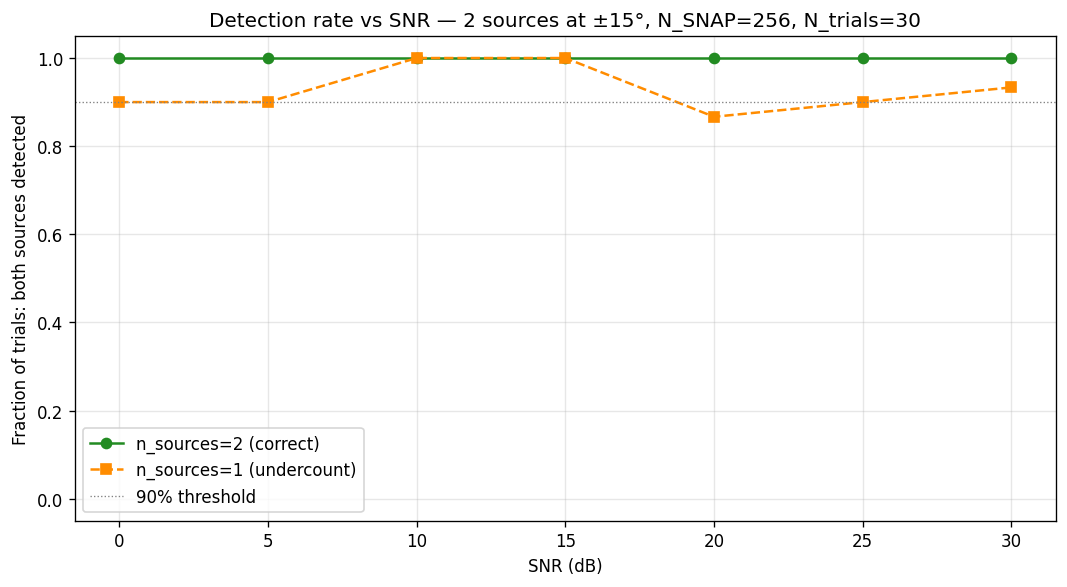

SNR vs detection rate (undercount n_sources=1):
  SNR=  0 dB  undercount=0.90  correct=1.00
  SNR=  5 dB  undercount=0.90  correct=1.00
  SNR= 10 dB  undercount=1.00  correct=1.00
  SNR= 15 dB  undercount=1.00  correct=1.00
  SNR= 20 dB  undercount=0.87  correct=1.00
  SNR= 25 dB  undercount=0.90  correct=1.00
  SNR= 30 dB  undercount=0.93  correct=1.00


In [6]:
SNR_VALS  = [0, 5, 10, 15, 20, 25, 30]
TOL_DEG   = 5.0
N_TRIALS2 = 30


def both_detected(peaks, sources, tol=TOL_DEG):
    return all(any(abs(p - az) < tol for p in peaks) for az, _ in sources)


rate_under = []   # n_sources=1 (wrong)
rate_exact = []   # n_sources=2 (correct)

for snr in SNR_VALS:
    det_under = det_exact = 0
    for trial in range(N_TRIALS2):
        R = make_csm(x_arr, y_arr, src_two, FREQ, snr, N_SNAP,
                     seed=trial * 1000 + int(snr))
        for n_spec, store in [(1, 'under'), (2, 'exact')]:
            m = beamform_music(x_arr, y_arr, R, FREQ, az_grid, n_sources=n_spec)
            pks = detect_peaks(az_grid, m)
            if both_detected(pks, src_two):
                if store == 'under':
                    det_under += 1
                else:
                    det_exact += 1
    rate_under.append(det_under / N_TRIALS2)
    rate_exact.append(det_exact / N_TRIALS2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(SNR_VALS, rate_exact, 'o-', color='forestgreen', label='n_sources=2 (correct)',
        linewidth=1.5)
ax.plot(SNR_VALS, rate_under, 's--', color='darkorange', label='n_sources=1 (undercount)',
        linewidth=1.5)
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.8, label='90% threshold')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Fraction of trials: both sources detected')
ax.set_title(f'Detection rate vs SNR — 2 sources at ±15°, N_SNAP={N_SNAP}, N_trials={N_TRIALS2}')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('music_detect_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()

print('SNR vs detection rate (undercount n_sources=1):')
for snr, r_u, r_e in zip(SNR_VALS, rate_under, rate_exact):
    print(f'  SNR={snr:3d} dB  undercount={r_u:.2f}  correct={r_e:.2f}')


## 4 — False Alarm Rate vs SNR for Overcounted MUSIC

Scenario: 1 true source at 20°, **n_sources=2 or 3** (overcount).
A false alarm is any detected peak more than 5° from the true source.
Count the fraction of trials that produce ≥1 false alarm.


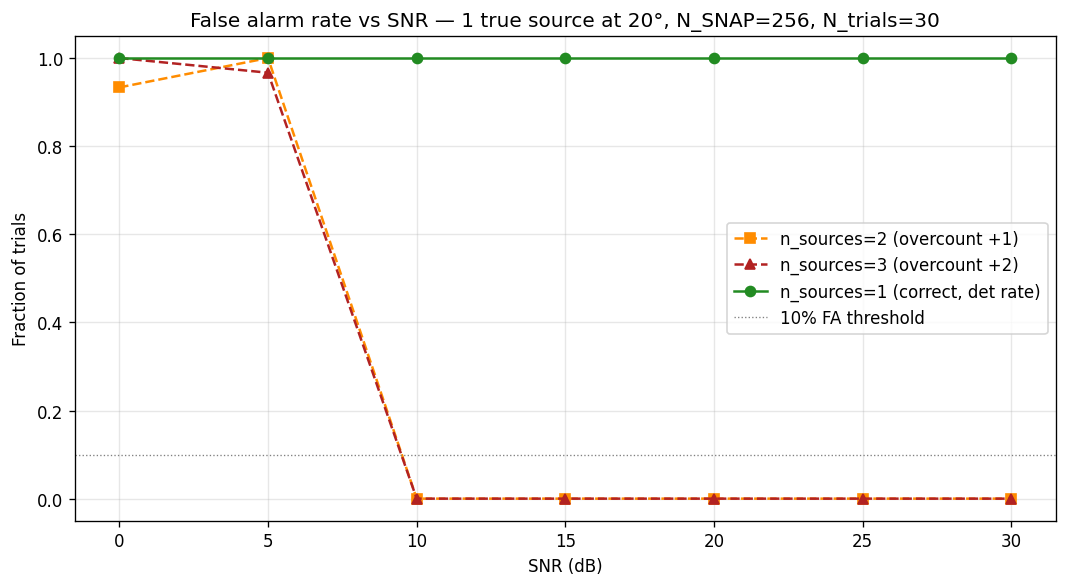

SNR vs false alarm rate (overcount):
  SNR=  0 dB  FA(n=2)=0.93  FA(n=3)=1.00  det(n=1)=1.00
  SNR=  5 dB  FA(n=2)=1.00  FA(n=3)=0.97  det(n=1)=1.00
  SNR= 10 dB  FA(n=2)=0.00  FA(n=3)=0.00  det(n=1)=1.00
  SNR= 15 dB  FA(n=2)=0.00  FA(n=3)=0.00  det(n=1)=1.00
  SNR= 20 dB  FA(n=2)=0.00  FA(n=3)=0.00  det(n=1)=1.00
  SNR= 25 dB  FA(n=2)=0.00  FA(n=3)=0.00  det(n=1)=1.00
  SNR= 30 dB  FA(n=2)=0.00  FA(n=3)=0.00  det(n=1)=1.00


In [7]:
fa_rate_2 = []   # n_sources=2 (overcount by 1)
fa_rate_3 = []   # n_sources=3 (overcount by 2)
det_rate_1 = []  # n_sources=1 (correct)


def has_false_alarm(peaks, true_source_az, tol=TOL_DEG):
    return any(abs(p - true_source_az) >= tol for p in peaks)


for snr in SNR_VALS:
    fa2 = fa3 = det1 = 0
    for trial in range(N_TRIALS2):
        R = make_csm(x_arr, y_arr, src_one, FREQ, snr, N_SNAP,
                     seed=trial * 2000 + int(snr))
        for n_spec, store in [(1, 'det1'), (2, 'fa2'), (3, 'fa3')]:
            m = beamform_music(x_arr, y_arr, R, FREQ, az_grid, n_sources=n_spec)
            pks = detect_peaks(az_grid, m)
            if store == 'det1':
                if any(abs(p - 20.0) < TOL_DEG for p in pks):
                    det1 += 1
            elif store == 'fa2':
                if has_false_alarm(pks, 20.0):
                    fa2 += 1
            else:
                if has_false_alarm(pks, 20.0):
                    fa3 += 1
    fa_rate_2.append(fa2 / N_TRIALS2)
    fa_rate_3.append(fa3 / N_TRIALS2)
    det_rate_1.append(det1 / N_TRIALS2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(SNR_VALS, fa_rate_2, 's--', color='darkorange', label='n_sources=2 (overcount +1)',
        linewidth=1.5)
ax.plot(SNR_VALS, fa_rate_3, '^--', color='firebrick',  label='n_sources=3 (overcount +2)',
        linewidth=1.5)
ax.plot(SNR_VALS, det_rate_1, 'o-', color='forestgreen', label='n_sources=1 (correct, det rate)',
        linewidth=1.5)
ax.axhline(0.1, color='gray', linestyle=':', linewidth=0.8, label='10% FA threshold')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Fraction of trials')
ax.set_title(f'False alarm rate vs SNR — 1 true source at 20°, N_SNAP={N_SNAP}, N_trials={N_TRIALS2}')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('music_fa_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()

print('SNR vs false alarm rate (overcount):')
for snr, f2, f3, d1 in zip(SNR_VALS, fa_rate_2, fa_rate_3, det_rate_1):
    print(f'  SNR={snr:3d} dB  FA(n=2)={f2:.2f}  FA(n=3)={f3:.2f}  det(n=1)={d1:.2f}')


## 5 — N_SNAP Effect on Undercount Robustness

Fix SNR=20 dB, 2 true sources at ±15°, n_sources=1 (undercount).
Sweep N_SNAP and measure both-source detection rate.
More snapshots improve CSM quality — does that rescue a wrong n_sources?


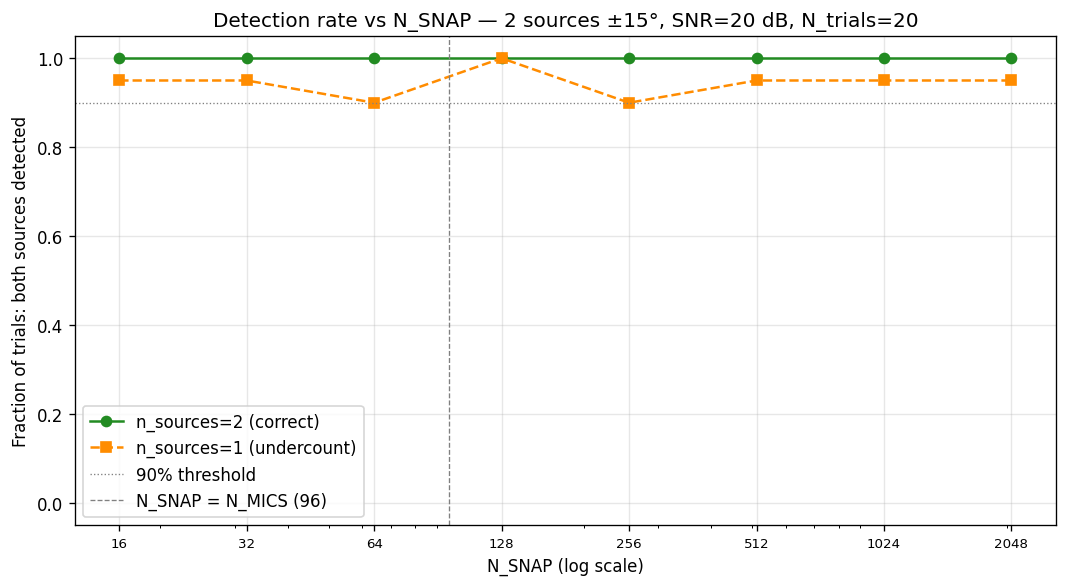

N_SNAP vs detection rate (undercount n_sources=1, SNR=20dB):
  N_SNAP=   16  undercount=0.95  correct=1.00
  N_SNAP=   32  undercount=0.95  correct=1.00
  N_SNAP=   64  undercount=0.90  correct=1.00
  N_SNAP=  128  undercount=1.00  correct=1.00
  N_SNAP=  256  undercount=0.90  correct=1.00
  N_SNAP=  512  undercount=0.95  correct=1.00
  N_SNAP= 1024  undercount=0.95  correct=1.00
  N_SNAP= 2048  undercount=0.95  correct=1.00


In [8]:
snap_vals  = [16, 32, 64, 128, 256, 512, 1024, 2048]
N_TRIALS3  = 20

rate_under_snap = []
rate_exact_snap = []

for n_snap in snap_vals:
    det_under = det_exact = 0
    for trial in range(N_TRIALS3):
        R = make_csm(x_arr, y_arr, src_two, FREQ, SNR_DB, n_snap,
                     seed=trial * 3000 + n_snap)
        for n_spec, store in [(1, 'under'), (2, 'exact')]:
            m = beamform_music(x_arr, y_arr, R, FREQ, az_grid, n_sources=n_spec)
            pks = detect_peaks(az_grid, m)
            if both_detected(pks, src_two):
                if store == 'under':
                    det_under += 1
                else:
                    det_exact += 1
    rate_under_snap.append(det_under / N_TRIALS3)
    rate_exact_snap.append(det_exact / N_TRIALS3)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(snap_vals, rate_exact_snap, 'o-', color='forestgreen',
        label='n_sources=2 (correct)', linewidth=1.5)
ax.plot(snap_vals, rate_under_snap, 's--', color='darkorange',
        label='n_sources=1 (undercount)', linewidth=1.5)
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.8, label='90% threshold')
ax.axvline(N_MICS, color='gray', linestyle='--', linewidth=0.8,
           label=f'N_SNAP = N_MICS ({N_MICS})')
ax.set_xscale('log')
ax.set_xlabel('N_SNAP (log scale)')
ax.set_ylabel('Fraction of trials: both sources detected')
ax.set_title(f'Detection rate vs N_SNAP — 2 sources ±15°, SNR={SNR_DB:.0f} dB, N_trials={N_TRIALS3}')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.set_xticks(snap_vals)
ax.set_xticklabels([str(n) for n in snap_vals], fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('music_detect_vs_snap.png', dpi=150, bbox_inches='tight')
plt.show()

print('N_SNAP vs detection rate (undercount n_sources=1, SNR=20dB):')
for n, r_u, r_e in zip(snap_vals, rate_under_snap, rate_exact_snap):
    print(f'  N_SNAP={n:5d}  undercount={r_u:.2f}  correct={r_e:.2f}')


## Summary


In [9]:
print('=== Undercount robustness (n_sources=1, true k=2, ±15° sources) ===')
print('Detection rate at 90% threshold:')
snr_90_under = next((s for s, r in zip(SNR_VALS, rate_under) if r >= 0.9), None)
snr_90_exact = next((s for s, r in zip(SNR_VALS, rate_exact) if r >= 0.9), None)
print(f'  Correct (n_sources=2): SNR >= {snr_90_exact} dB')
print(f'  Undercount (n_sources=1): SNR >= {snr_90_under} dB  (None = never reached)')
print()
print('=== Overcount false alarms (n_sources=2/3, true k=1, source @ 20°) ===')
print('SNR where FA rate drops below 10%:')
snr_fa2_ok = next((s for s, r in zip(SNR_VALS, fa_rate_2) if r <= 0.1), None)
snr_fa3_ok = next((s for s, r in zip(SNR_VALS, fa_rate_3) if r <= 0.1), None)
print(f'  Overcount +1 (n_sources=2): SNR >= {snr_fa2_ok} dB')
print(f'  Overcount +2 (n_sources=3): SNR >= {snr_fa3_ok} dB')
print()
print('=== N_SNAP effect on undercount (SNR=20dB, n_sources=1, true k=2) ===')
snap_90_under = next((n for n, r in zip(snap_vals, rate_under_snap) if r >= 0.9), None)
snap_90_exact = next((n for n, r in zip(snap_vals, rate_exact_snap) if r >= 0.9), None)
print(f'  Correct (n_sources=2): N_SNAP >= {snap_90_exact}')
print(f'  Undercount (n_sources=1): N_SNAP >= {snap_90_under}  (None = never reached)')


=== Undercount robustness (n_sources=1, true k=2, ±15° sources) ===
Detection rate at 90% threshold:
  Correct (n_sources=2): SNR >= 0 dB
  Undercount (n_sources=1): SNR >= 0 dB  (None = never reached)

=== Overcount false alarms (n_sources=2/3, true k=1, source @ 20°) ===
SNR where FA rate drops below 10%:
  Overcount +1 (n_sources=2): SNR >= 10 dB
  Overcount +2 (n_sources=3): SNR >= 10 dB

=== N_SNAP effect on undercount (SNR=20dB, n_sources=1, true k=2) ===
  Correct (n_sources=2): N_SNAP >= 16
  Undercount (n_sources=1): N_SNAP >= 16  (None = never reached)
